# Test the interventions:


## Baseline Model Construction and Hypothesis Testing

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \


The values converged in the 5 state (e <= 0.001)

Baseline Simulation Results:
    Pro-Mit  Monitoring   Con & Res    Budget       OUV  Unfenced    OGE  \
0      0.0     0.100000        0.0  0.250000  0.750000        1.0  0.25   
1      0.0     0.404319        0.0  0.503125  0.817574        1.0  0.25   
2      0.0     0.404319        0.0  0.503125  0.710231        1.0  0.25   
3      0.0     0.404319        0.0  0.503125  0.700012        1.0  0.25   
4      0.0     0.404319        0.0  0.503125  0.700012        1.0  0.25   

   Usage   Preservation   Flooding  ...  Temperature        LA   HR    TF  \
0     0.0            0.0       0.0  ...          0.1  0.100000  0.1  0.25   
1     0.0            0.0       0.0  ...          0.1  0.468791  0.1  0.25   
2     0.0            0.0       0.0  ...          0.1  0.421038  0.1  0.25   
3     0.0            0.0       0.0  ...          0.1  0.421038  0.1  0.25   
4     0.0            0.0       0.0  ...          0.1  0.421038  0.1  0.25   

    Ph

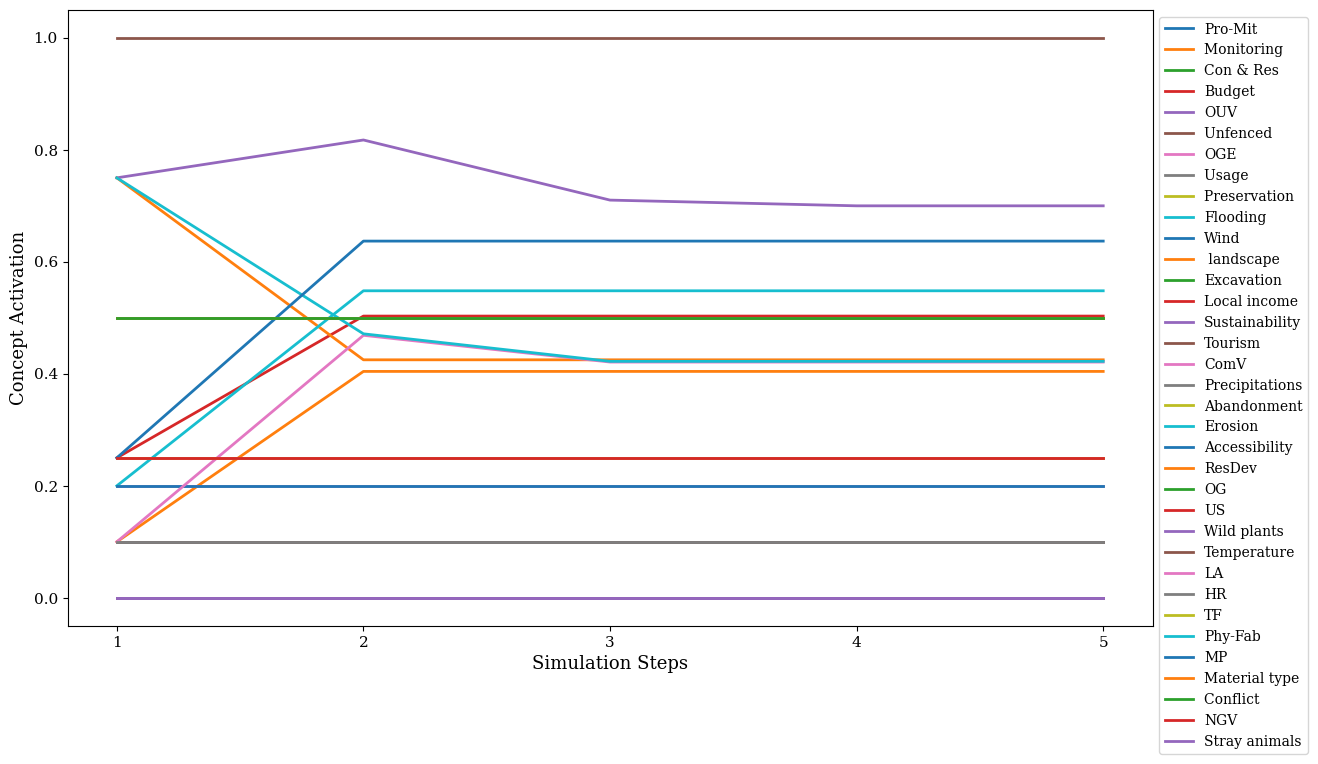

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fcmpy.simulator.transfer import Sigmoid
from fcmpy import FcmSimulator
import os

# File paths
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"

# Load the FCM adjacency matrix
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()  # Extract concept IDs
weight_matrix = fcm_data.astype(float).values  # Convert to numeric numpy array

# Load concept labels
labels_df = pd.read_csv(labels_path)

# Create a dictionary mapping Concept ID to Label
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))

# Replace concept IDs with labels
concept_labels = [concept_label_map.get(concept_id, concept_id) for concept_id in concept_ids]

# Load initial values from experts
def get_initial_values():
    initial_values_df = pd.read_csv(initial_values_path)
    
    # Ensure correct column selection
    if 'Concept ID' not in initial_values_df.columns or 'Initial Value' not in initial_values_df.columns:
        raise ValueError("Initial values CSV must contain 'Concept ID' and 'Initial Value' columns.")
    
    # Create a dictionary with default 0.0 for missing concepts
    initial_state = {
        concept_label_map.get(concept, concept): initial_values_df.loc[initial_values_df['Concept ID'] == concept, 'Initial Value'].values[0]
        if concept in initial_values_df['Concept ID'].values else 0.0
        for concept in concept_ids
    }
    return initial_state

# Get the initial state
init_state = get_initial_values()

# Initialize the simulator
sim = FcmSimulator()

# Function to run the simulation and store results
def simulate_fcm(initial_state, weight_matrix, method_name):
    # Copy the weight matrix to avoid modifying the original
    modified_weight_matrix = weight_matrix.copy()
    
    # Identify and deactivate concepts with zero initial values
    inactive_concepts = [concept for concept, value in initial_state.items() if value == 0.0]
    for concept in inactive_concepts:
        if concept in concept_labels:
            concept_index = concept_labels.index(concept)
            modified_weight_matrix[:, concept_index] = 0  # Set all incoming weights to 0
            modified_weight_matrix[concept_index, :] = 0  # Set all outgoing weights to 0
    
    # Run the simulation
    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=modified_weight_matrix,
        transfer='sigmoid',  # Use Sigmoid transfer function
        inference='kosko',  # Use Kosko inference method
        thresh=0.001,
        iterations=20,
        l=1
    )

# Run simulation
result = simulate_fcm(init_state, weight_matrix, method_name="Kosko with Sigmoid")

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(result, columns=concept_labels)

# Display results
print("\nBaseline Simulation Results:\n", results_df)

# Plot results
plt.figure(figsize=(14, 8))

for concept in concept_labels:
    plt.plot(results_df.index, results_df[concept], label=concept)

plt.xlabel('Simulation Steps')
plt.ylabel('Concept Activation')
plt.title('')

# Show only first 5 iterations with clean integer labels
plt.xticks(ticks=range(5), labels=range(1, 6))

# Remove grid (grey lines)
plt.grid(False)

plt.legend(loc='best', bbox_to_anchor=(1, 1))

# Create results folder if it doesn't exist
output_folder = "Appendices"
os.makedirs(output_folder, exist_ok=True)

# Save simulation results as CSV
results_df.to_csv(os.path.join(output_folder, "fcm_simulation_results.csv"), index=True)

# Save figure in PNG and PDF formats
plt.savefig(os.path.join(output_folder, "fcm_simulation_plot.png"), bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(output_folder, "fcm_simulation_plot.pdf"), bbox_inches='tight')

print("Results and figures saved successfully in the 'Appendices' folder.")
plt.show()


/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \


The values converged in the 5 state (e <= 0.001)
Simulation results saved at: Appendices/fcm_baseline_simulation_results.csv
Figure saved as PNG: Appendices/baseline activation levels for all concepts_plot.png
Figure saved as PDF: Appendices/baseline activation levels for all concepts_plot.pdf


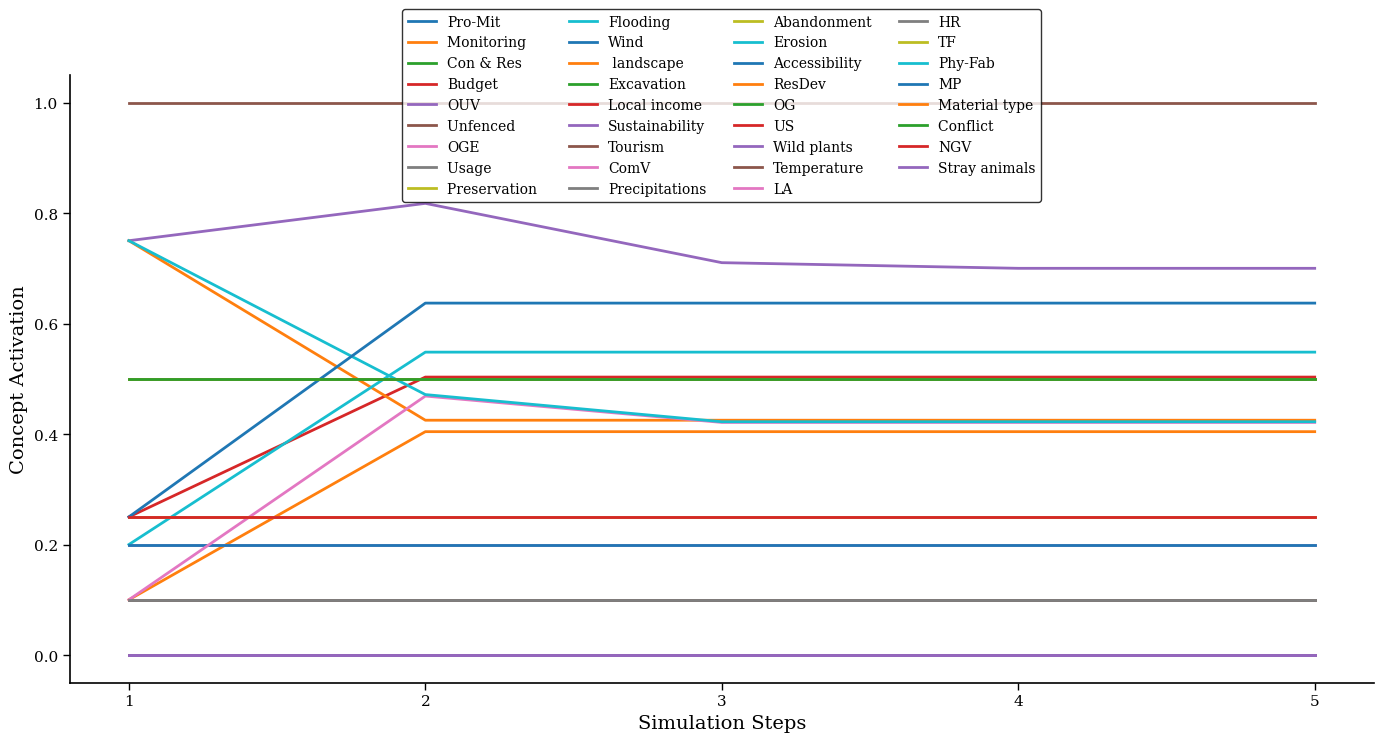

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fcmpy import FcmSimulator
import os

# -------------------------------
# GLOBAL PUBLICATION STYLE
# -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6
})

# -------------------------------
# File paths
# -------------------------------
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_folder = "Appendices"
os.makedirs(output_folder, exist_ok=True)

# -------------------------------
# Load FCM adjacency matrix
# -------------------------------
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# -------------------------------
# Load concept labels
# -------------------------------
labels_df = pd.read_csv(labels_path)
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))
concept_labels = [concept_label_map.get(cid, cid) for cid in concept_ids]

# -------------------------------
# Load initial values
# -------------------------------
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    if 'Concept ID' not in df.columns or 'Initial Value' not in df.columns:
        raise ValueError("Initial values CSV must contain 'Concept ID' and 'Initial Value'")
    return {
        concept_label_map.get(concept, concept): df.loc[df['Concept ID'] == concept, 'Initial Value'].values[0]
        if concept in df['Concept ID'].values else 0.0
        for concept in concept_ids
    }

init_state = get_initial_values()
sim = FcmSimulator()

# -------------------------------
# FCM simulation function
# -------------------------------
def simulate_fcm(initial_state, weight_matrix):
    mod_matrix = weight_matrix.copy()
    inactive = [c for c, v in initial_state.items() if v == 0.0]
    for c in inactive:
        if c in concept_labels:
            idx = concept_labels.index(c)
            mod_matrix[:, idx] = 0
            mod_matrix[idx, :] = 0
    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=mod_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=20,
        l=1
    )

# -------------------------------
# Run simulation
# -------------------------------
result = simulate_fcm(init_state, weight_matrix)
results_df = pd.DataFrame(result, columns=concept_labels)

# -------------------------------
# Save results CSV
# -------------------------------
results_csv_path = os.path.join(output_folder, "fcm_baseline_simulation_results.csv")
results_df.to_csv(results_csv_path, index=True)
print(f"Simulation results saved at: {results_csv_path}")

# -------------------------------
# Plot results - publication style
# -------------------------------
plt.figure(figsize=(14, 8))

for concept in concept_labels:
    plt.plot(
        results_df.index,
        results_df[concept],
        label=concept
    )

plt.xlabel('Simulation Steps', fontsize=14)
plt.ylabel('Concept Activation', fontsize=14)

# Only show first 5 iterations for clarity
plt.xticks(ticks=range(5), labels=range(1, 6))

# Remove top/right spines for clean style
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(direction='out', length=5, width=1)

plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=True, edgecolor='black', fontsize=10)
plt.tight_layout(rect=[0,0,1,0.95])

# -------------------------------
# Save figure as PNG and PDF
# -------------------------------
png_path = os.path.join(output_folder, "baseline activation levels for all concepts_plot.png")
pdf_path = os.path.join(output_folder, "baseline activation levels for all concepts_plot.pdf")
plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

print(f"Figure saved as PNG: {png_path}")
print(f"Figure saved as PDF: {pdf_path}")

plt.show()

### The baseline activation levels for the core outcome concepts 

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \


The values converged in the 5 state (e <= 0.001)


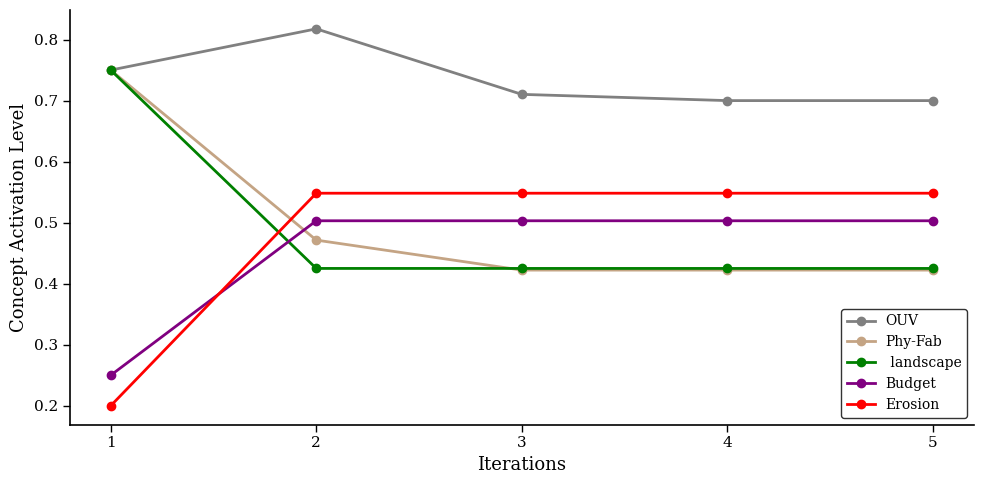

✅ Simulation completed. Figure saved to: Results/Selected_Concept_Activation.png


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fcmpy.simulator.transfer import Sigmoid
from fcmpy import FcmSimulator
import os

# ==============================
# FILE PATHS
# ==============================
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_dir = "Results"
output_file = os.path.join(output_dir, "Selected_Concept_Activation.png")

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# ==============================
# LOAD DATA
# ==============================

# Load the FCM adjacency matrix
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()           # Extract concept IDs
weight_matrix = fcm_data.astype(float).values     # Convert to numeric numpy array

# Load concept labels
labels_df = pd.read_csv(labels_path)

# Create a dictionary mapping Concept ID to Label
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))

# Replace concept IDs with labels
concept_labels = [concept_label_map.get(concept_id, concept_id) for concept_id in concept_ids]

# ==============================
# INITIAL VALUES
# ==============================
def get_initial_values():
    """Load and map initial concept activation values from CSV."""
    initial_values_df = pd.read_csv(initial_values_path)
    
    # Ensure required columns are present
    if 'Concept ID' not in initial_values_df.columns or 'Initial Value' not in initial_values_df.columns:
        raise ValueError("Initial values CSV must contain 'Concept ID' and 'Initial Value' columns.")
    
    # Create dictionary for initial state (default 0.0 for missing concepts)
    initial_state = {
        concept_label_map.get(concept, concept): initial_values_df.loc[
            initial_values_df['Concept ID'] == concept, 'Initial Value'
        ].values[0] if concept in initial_values_df['Concept ID'].values else 0.0
        for concept in concept_ids
    }
    return initial_state

# Get the initial state
init_state = get_initial_values()

# ==============================
# SIMULATION
# ==============================
sim = FcmSimulator()

def simulate_fcm(initial_state, weight_matrix, method_name):
    """Run the FCM simulation using Kosko inference and sigmoid transfer."""
    # Copy the matrix to avoid modification
    modified_weight_matrix = weight_matrix.copy()
    
    # Identify and deactivate inactive concepts (zero initial values)
    inactive_concepts = [concept for concept, value in initial_state.items() if value == 0.0]
    for concept in inactive_concepts:
        if concept in concept_labels:
            idx = concept_labels.index(concept)
            modified_weight_matrix[:, idx] = 0  # Zero incoming edges
            modified_weight_matrix[idx, :] = 0  # Zero outgoing edges
    
    # Run the simulation
    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=modified_weight_matrix,
        transfer='sigmoid',    # Sigmoid transfer function
        inference='kosko',     # Kosko inference method
        thresh=0.001,
        iterations=20,
        l=1
    )

# Run simulation
result = simulate_fcm(init_state, weight_matrix, method_name="Kosko with Sigmoid")

# ==============================
# RESULTS PROCESSING
# ==============================
# Convert results to DataFrame and start iterations from 1 (not 0)
results_df = pd.DataFrame(result, columns=concept_labels)
results_df.index = np.arange(1, len(results_df) + 1)

# Select target concepts to visualize
target_concepts = ["C1", "C2", "C3", "C7", "C8"]
target_labels = [concept_label_map.get(c, c) for c in target_concepts]

# ==============================

# Define custom colors for selected concepts
concept_colors = {
    concept_label_map.get("C1", "C1"): "gray",
    concept_label_map.get("C2", "C2"): "#C4A484",  # lighter brown
    concept_label_map.get("C3", "C3"): "green",
    concept_label_map.get("C7", "C7"): "purple",
    concept_label_map.get("C8", "C8"): "red"
}
# PLOTTING

# ==============================
# PUBLICATION-READY STYLE
# ==============================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6
})
# ==============================
plt.figure(figsize=(10, 5))

for label in target_labels:
    if label in results_df.columns:
        plt.plot(
            results_df.index,
            results_df[label],
            label=label,
            color=concept_colors.get(label, "black"),
            marker='o'
        )

# Labels
plt.xlabel('Iterations')
plt.ylabel('Concept Activation Level')

# Clean axes (publication style)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Keep left & bottom spines slightly thicker
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Ticks
plt.xticks(np.arange(1, len(results_df) + 1, 1))
plt.tick_params(direction='out', length=5, width=1)

# Legend (clean box)
plt.legend(
    loc='best',
    frameon=True,
    edgecolor='black'
)

plt.grid(False)
plt.tight_layout()

# Save and display
# Save PNG
plt.savefig(output_file, bbox_inches='tight', dpi=300)

# Save PDF
pdf_output_file = os.path.join(output_dir, "Selected_Concept_Activation.pdf")
plt.savefig(pdf_output_file, bbox_inches='tight')

plt.show()

print(f"✅ Simulation completed. Figure saved to: {output_file}")


## Flooding scenarios

### Scenario analysis with FCMs:  flood without and flood with improvement

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure th

The values converged in the 5 state (e <= 0.001)
The values converged in the 5 state (e <= 0.001)
The values converged in the 6 state (e <= 0.001)


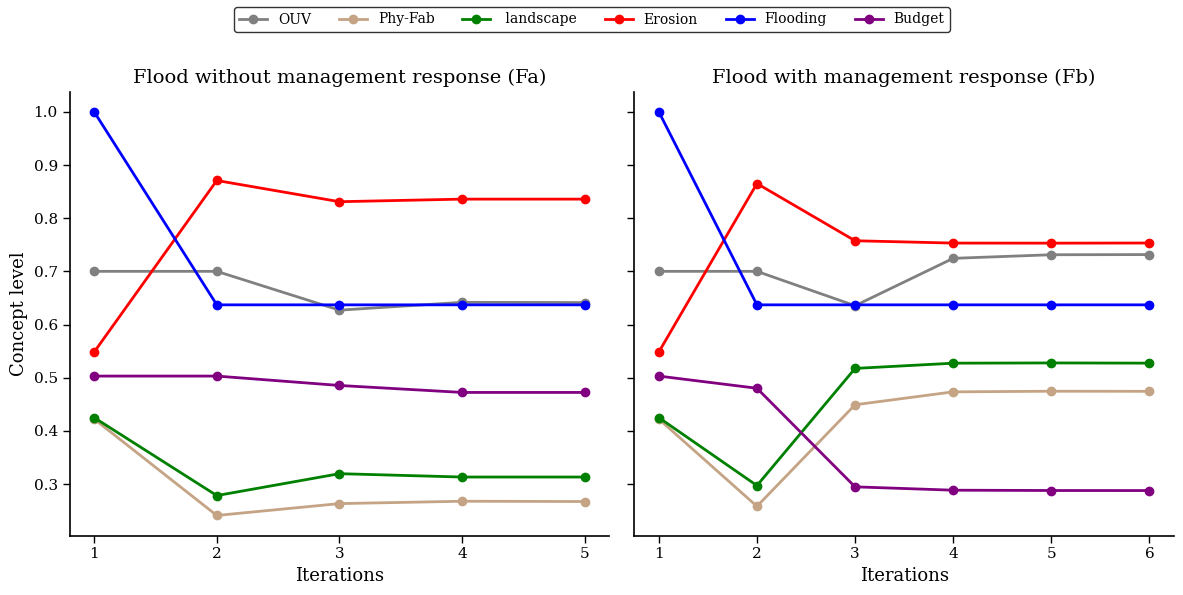

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from fcmpy import FcmSimulator
import os

# -------------------------------
# File paths
# -------------------------------
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_dir = "Results"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------
# Load FCM data
# -------------------------------
fcm_data = pd.read_csv(matrix_path, index_col=0)
concepts = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# -------------------------------
# Load initial values
# -------------------------------
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    return {
        concept: float(df.loc[df['Concept ID'] == concept, 'Initial Value'].values[0])
        if concept in df['Concept ID'].values else 0.0
        for concept in concepts
    }

init_state = get_initial_values()
sim = FcmSimulator()

# -------------------------------
# FCM simulation function
# -------------------------------
def simulate_fcm(initial_state, weight_matrix, iterations=20):
    modified_weight_matrix = weight_matrix.copy()
    inactive_concepts = [c for c, v in initial_state.items() if float(v) == 0.0]
    for concept in inactive_concepts:
        if concept in concepts:
            idx = concepts.index(concept)
            modified_weight_matrix[:, idx] = 0
            modified_weight_matrix[idx, :] = 0
    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=modified_weight_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=iterations,
        l=1
    )

# -------------------------------
# Baseline simulation
# -------------------------------
baseline_result = simulate_fcm(init_state, weight_matrix)
baseline_df = pd.DataFrame(baseline_result, columns=concepts)
last_values = {k: float(v) for k, v in baseline_df.iloc[-1].to_dict().items()}

# -------------------------------
# Intervention function
# -------------------------------
def apply_intervention(base_state, name):
    updated = base_state.copy()
    if name == "flood":
        updated.update({'C15': 1.0, 'C11': 1.0})
    elif name == "flood with improvement":
        updated.update({'C15': 1.0, 'C11': 1.0, 'C21': 0.1, 'C27': 1.0, 'C28': 0.1})
    return updated

scenarios = {
    "Flood without management response (Fa)": apply_intervention(last_values, "flood"),
    "Flood with management response (Fb)": apply_intervention(last_values, "flood with improvement"),
}

# -------------------------------
# Load concept labels for plotting
# -------------------------------
labels_df = pd.read_csv(labels_path)
label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))

# Target concepts
target_concepts = ["C1", "C2", "C3", "C8", "C15", "C7"]
target_labels = [label_map.get(c, c) for c in target_concepts]

# -------------------------------
# -------------------------------
# Concept colors (consistent style)
# -------------------------------
concept_colors = {
    "C1": "gray",
    "C2": "#C4A484",  # light brown
    "C3": "green",
    "C7": "purple",
    "C8": "red",
    "C15": "blue"
}
# -------------------------------
# Horizontal subplot plotting
# -------------------------------
def plot_horizontal_scenarios(scenario_dfs, scenario_names, target_concepts, target_labels):
    fig, axes = plt.subplots(1, len(scenario_dfs), figsize=(6*len(scenario_dfs), 6), sharey=True)

    if len(scenario_dfs) == 1:
        axes = [axes]

    for ax, df, name in zip(axes, scenario_dfs, scenario_names):
        x_values = range(1, len(df)+1)

        for concept, label in zip(target_concepts, target_labels):
            if concept in df.columns:
                ax.plot(
                    x_values,
                    df[concept],
                    label=label,
                    marker='o',
                    color=concept_colors.get(concept, "black")
                )

        ax.set_title(name)
        ax.set_xlabel("Iterations")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        # --- Clean publication axes ---
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.tick_params(direction='out', length=5, width=1)

        ax.grid(False)

    axes[0].set_ylabel("Concept level")

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', fontsize=10, ncol=len(target_labels), frameon=True, edgecolor='black')

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    # Save PNG
    png_file = os.path.join(output_dir, "Flooding_Scenarios.png")
    plt.savefig(png_file, dpi=300, bbox_inches='tight')

    # Save PDF
    pdf_file = os.path.join(output_dir, "Flooding_Scenarios.pdf")
    plt.savefig(pdf_file, bbox_inches='tight')

    plt.show()


# -------------------------------
# Run simulations, save CSVs
# -------------------------------
scenario_dfs = []
scenario_names = []

for name, state in scenarios.items():
    df_result = pd.DataFrame(simulate_fcm(state, weight_matrix), columns=concepts)

    # Save CSV
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    csv_path = os.path.join(output_dir, f"{safe_name}.csv")
    df_result.to_csv(csv_path, index=False)

    scenario_dfs.append(df_result)
    scenario_names.append(name)

# -------------------------------
# Plot results
# -------------------------------
plot_horizontal_scenarios(scenario_dfs, scenario_names, target_concepts, target_labels)

## Tourism scenarios

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure th

The values converged in the 5 state (e <= 0.001)
The values converged in the 5 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)


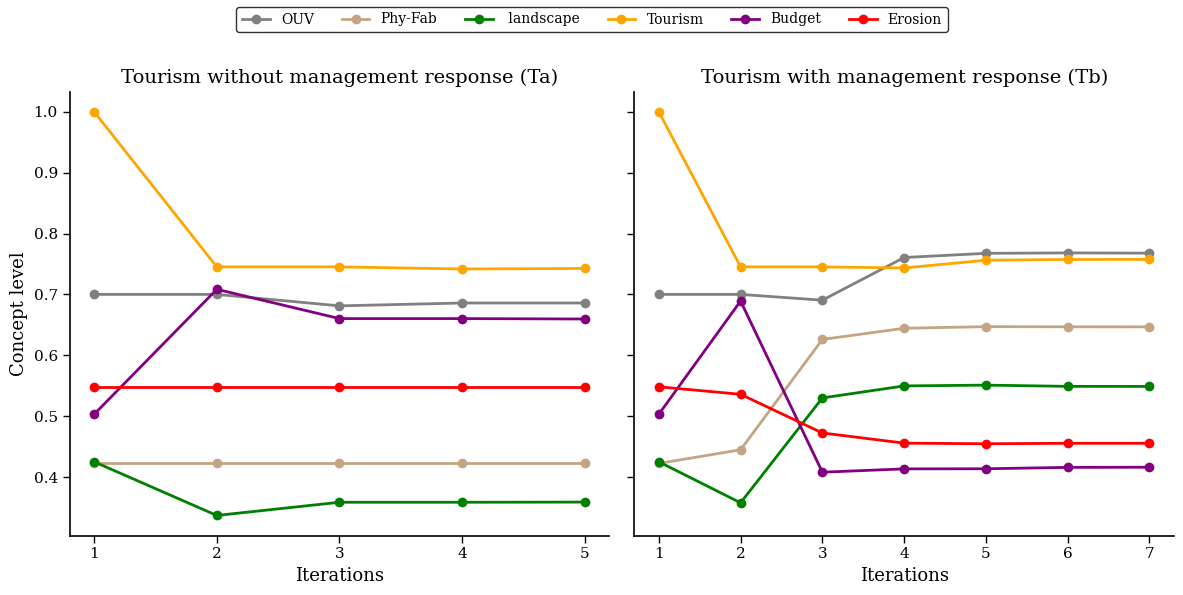

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from fcmpy import FcmSimulator
import os

# -------------------------------
# GLOBAL PUBLICATION STYLE
# -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6
})

# -------------------------------
# File paths
# -------------------------------
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_dir = "Results"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------
# Load FCM adjacency matrix
# -------------------------------
fcm_data = pd.read_csv(matrix_path, index_col=0)
concepts = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# -------------------------------
# Load initial values
# -------------------------------
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    return {
        concept: df.loc[df['Concept ID'] == concept, 'Initial Value'].values[0]
        if concept in df['Concept ID'].values else 0.0
        for concept in concepts
    }

init_state = get_initial_values()
sim = FcmSimulator()

# -------------------------------
# FCM simulation function
# -------------------------------
def simulate_fcm(initial_state, weight_matrix):
    modified_weight_matrix = weight_matrix.copy()
    inactive_concepts = [c for c, v in initial_state.items() if v == 0.0]

    for concept in inactive_concepts:
        if concept in concepts:
            idx = concepts.index(concept)
            modified_weight_matrix[:, idx] = 0
            modified_weight_matrix[idx, :] = 0

    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=modified_weight_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=20,
        l=1
    )

# -------------------------------
# Baseline simulation
# -------------------------------
baseline_result = simulate_fcm(init_state, weight_matrix)
baseline_df = pd.DataFrame(baseline_result, columns=concepts)
last_values = baseline_df.iloc[-1].to_dict()

# -------------------------------
# Intervention scenarios
# -------------------------------
def apply_intervention(name, initial_state):
    state = initial_state.copy()
    if name == "Tourism without management response (Ta)":
        state.update({'C40': 1})
    elif name == "Tourism with management response (Tb)":
        state.update({'C40': 1, 'C21': 0.1, 'C28': 0.1, 'C27': 1})
    return state

scenarios = {
    "Tourism without management response (Ta)": apply_intervention(
        "Tourism without management response (Ta)", last_values),
    "Tourism with management response (Tb)": apply_intervention(
        "Tourism with management response (Tb)", last_values)
}

# -------------------------------
# Load concept labels
# -------------------------------
labels_df = pd.read_csv(labels_path)
label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))

# Target concepts
target_concepts = ["C1", "C2", "C3", "C40", "C7", "C8"]
target_labels = [label_map.get(c, c) for c in target_concepts]

# -------------------------------
# Concept colors (consistent)
# -------------------------------
concept_colors = {
    "C1": "gray",
    "C2": "#C4A484",
    "C3": "green",
    "C7": "purple",
    "C8": "red",
    "C40": "orange"
}

# -------------------------------
# Horizontal subplot plotting
# -------------------------------
def plot_horizontal_scenarios(scenario_dfs, scenario_names, target_concepts, target_labels):
    fig, axes = plt.subplots(1, len(scenario_dfs), figsize=(6*len(scenario_dfs), 6), sharey=True)

    if len(scenario_dfs) == 1:
        axes = [axes]

    for ax, df, name in zip(axes, scenario_dfs, scenario_names):
        x_values = range(1, len(df)+1)

        for concept, label in zip(target_concepts, target_labels):
            if concept in df.columns:
                ax.plot(
                    x_values,
                    df[concept],
                    label=label,
                    marker='o',
                    color=concept_colors.get(concept, "black")
                )

        ax.set_title(name)
        ax.set_xlabel("Iterations")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        # --- Clean publication axes ---
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.tick_params(direction='out', length=5, width=1)

        ax.grid(False)

    axes[0].set_ylabel("Concept level")

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', fontsize=10, ncol=len(target_labels), frameon=True, edgecolor='black')

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    # Save PNG
    png_file = os.path.join(output_dir, "Tourism_Scenarios.png")
    plt.savefig(png_file, dpi=300, bbox_inches='tight')

    # Save PDF
    pdf_file = os.path.join(output_dir, "Tourism_Scenarios.pdf")
    plt.savefig(pdf_file, bbox_inches='tight')

    plt.show()

# -------------------------------
# Run simulations, save CSVs
# -------------------------------
scenario_dfs = []
scenario_names = []

for name, state in scenarios.items():
    df_result = pd.DataFrame(simulate_fcm(state, weight_matrix), columns=concepts)

    # Save CSV
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    csv_path = os.path.join(output_dir, f"{safe_name}.csv")
    df_result.to_csv(csv_path, index=False)

    scenario_dfs.append(df_result)
    scenario_names.append(name)

# -------------------------------
# Plot results
# -------------------------------
plot_horizontal_scenarios(scenario_dfs, scenario_names, target_concepts, target_labels)

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure th

The values converged in the 5 state (e <= 0.001)
The values converged in the 5 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)


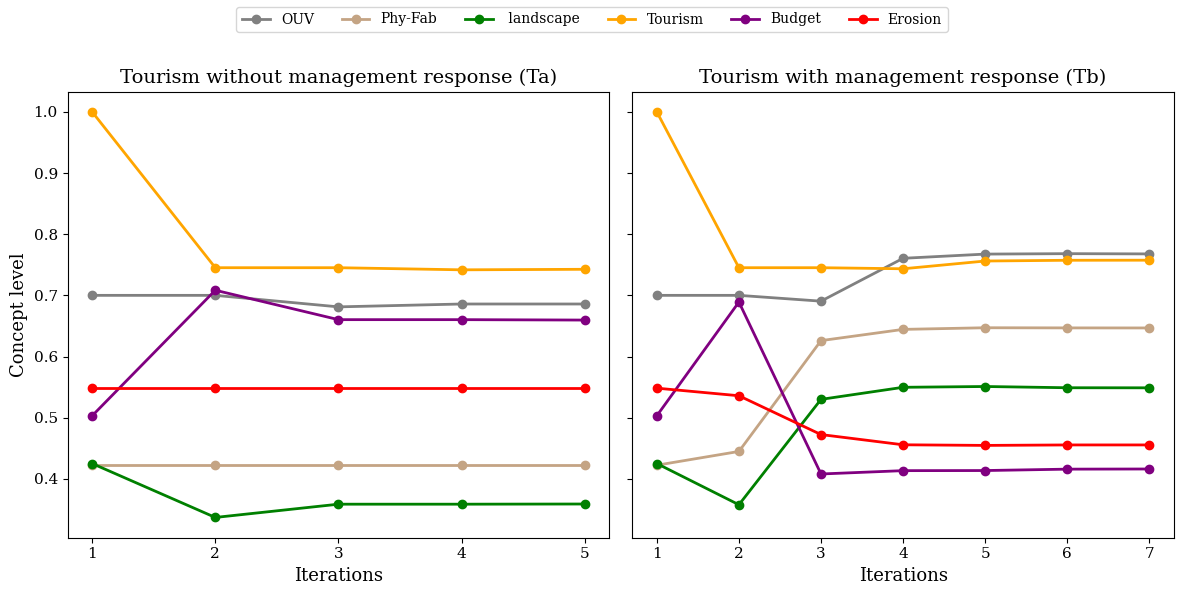

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from fcmpy import FcmSimulator
import os

# -------------------------------
# File paths
# -------------------------------
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_dir = "Results"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------
# Load FCM adjacency matrix
# -------------------------------
fcm_data = pd.read_csv(matrix_path, index_col=0)
concepts = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# -------------------------------
# Load initial values
# -------------------------------
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    return {
        concept: df.loc[df['Concept ID'] == concept, 'Initial Value'].values[0]
        if concept in df['Concept ID'].values else 0.0
        for concept in concepts
    }

init_state = get_initial_values()
sim = FcmSimulator()

# -------------------------------
# FCM simulation function
# -------------------------------
def simulate_fcm(initial_state, weight_matrix):
    modified_weight_matrix = weight_matrix.copy()
    inactive_concepts = [c for c, v in initial_state.items() if v == 0.0]
    for concept in inactive_concepts:
        if concept in concepts:
            idx = concepts.index(concept)
            modified_weight_matrix[:, idx] = 0
            modified_weight_matrix[idx, :] = 0
    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=modified_weight_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=20,
        l=1
    )

# -------------------------------
# Baseline simulation
# -------------------------------
baseline_result = simulate_fcm(init_state, weight_matrix)
baseline_df = pd.DataFrame(baseline_result, columns=concepts)
last_values = baseline_df.iloc[-1].to_dict()

# -------------------------------
# Intervention scenarios
# -------------------------------
def apply_intervention(name, initial_state):
    state = initial_state.copy()
    if name == "Tourism without management response (Ta)":
        state.update({'C40': 1})
    elif name == "Tourism with management response (Tb)":
        state.update({'C40': 1, 'C21': 0.1, 'C28': 0.1, 'C27': 1})
    return state

scenarios = {
    "Tourism without management response (Ta)": apply_intervention(
        "Tourism without management response (Ta)", last_values),
    "Tourism with management response (Tb)": apply_intervention(
        "Tourism with management response (Tb)", last_values)
}

# -------------------------------
# Load concept labels
# -------------------------------
labels_df = pd.read_csv(labels_path)
label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))

# Target concepts
target_concepts = ["C1", "C2", "C3", "C40", "C7", "C8"]
target_labels = [label_map.get(c, c) for c in target_concepts]

# -------------------------------
# Concept colors (consistent)
# -------------------------------
concept_colors = {
    "C1": "gray",
    "C2": "#C4A484",  # light brown
    "C3": "green",
    "C7": "purple",
    "C8": "red",
    "C40": "orange"
}

# -------------------------------
# Horizontal subplot plotting
# -------------------------------
def plot_horizontal_scenarios(scenario_dfs, scenario_names, target_concepts, target_labels):
    fig, axes = plt.subplots(1, len(scenario_dfs), figsize=(6*len(scenario_dfs), 6), sharey=True)

    if len(scenario_dfs) == 1:
        axes = [axes]

    for ax, df, name in zip(axes, scenario_dfs, scenario_names):
        x_values = range(1, len(df)+1)

        for concept, label in zip(target_concepts, target_labels):
            if concept in df.columns:
                ax.plot(
                    x_values,
                    df[concept],
                    label=label,
                    marker='o',
                    linewidth=2,
                    color=concept_colors.get(concept, "black")
                )

        ax.set_title(name)
        ax.set_xlabel("Iterations")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(False)

    axes[0].set_ylabel("Concept level")

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', fontsize=10, ncol=len(target_labels))

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    # Save PNG
    png_file = os.path.join(output_dir, "Tourism_Scenarios.png")
    plt.savefig(png_file, dpi=300, bbox_inches='tight')

    # Save PDF
    pdf_file = os.path.join(output_dir, "Tourism_Scenarios.pdf")
    plt.savefig(pdf_file, bbox_inches='tight')

    plt.show()

# -------------------------------
# Run simulations, save CSVs
# -------------------------------
scenario_dfs = []
scenario_names = []

for name, state in scenarios.items():
    df_result = pd.DataFrame(simulate_fcm(state, weight_matrix), columns=concepts)

    # Save CSV
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    csv_path = os.path.join(output_dir, f"{safe_name}.csv")
    df_result.to_csv(csv_path, index=False)

    scenario_dfs.append(df_result)
    scenario_names.append(name)

# -------------------------------
# Plot results
# -------------------------------
plot_horizontal_scenarios(scenario_dfs, scenario_names, target_concepts, target_labels)

## "Flood + Tourism with management responses " 
.."In this scenario, to simulate the activation of Tourism during a flood event, we set the activation levels of both 'Tourism' and 'Tourism Facilities' to 0.5 instead of 1." 

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure th

The values converged in the 5 state (e <= 0.001)
The values converged in the 2 state (e <= 0.001)
The values converged in the 6 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)


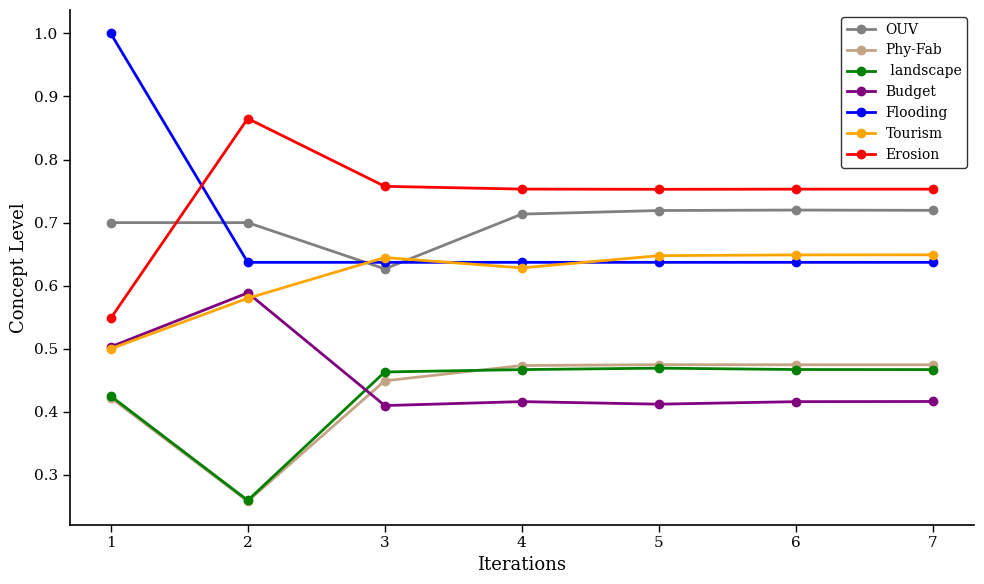

CSV saved at: Results/comparison_table.csv
Figure saved (PNG): Results/FTb_Scenario_Concept_Levels.png
Figure saved (PDF): Results/FTb_Scenario_Concept_Levels.pdf


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fcmpy import FcmSimulator
import os

# =========================
# GLOBAL PUBLICATION STYLE
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6
})

# --- File paths ---
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_folder = "Results"
comparison_csv_filename = "comparison_table.csv"

os.makedirs(output_folder, exist_ok=True)

# --- Load FCM matrix ---
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# --- Load concept labels ---
labels_df = pd.read_csv(labels_path)
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))
concept_labels = [concept_label_map.get(cid, cid) for cid in concept_ids]

# --- Load initial values ---
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    return {
        concept_label_map.get(concept, concept): df.loc[df['Concept ID'] == concept, 'Initial Value'].values[0]
        if concept in df['Concept ID'].values else 0.0
        for concept in concept_ids
    }

init_state = get_initial_values()
sim = FcmSimulator()

# --- Simulation ---
def simulate_fcm(initial_state, weight_matrix):
    mod_matrix = weight_matrix.copy()
    inactive = [c for c, v in initial_state.items() if v == 0.0]
    for c in inactive:
        if c in concept_labels:
            idx = concept_labels.index(c)
            mod_matrix[:, idx] = 0
            mod_matrix[idx, :] = 0
    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=mod_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=20,
        l=1
    )

# --- Baseline ---
baseline_result = simulate_fcm(init_state, weight_matrix)
baseline_df = pd.DataFrame(baseline_result, columns=concept_labels)
last_values = baseline_df.iloc[-1].to_dict()

# --- Interventions ---
def apply_intervention(name, base_state):
    updated = base_state.copy()
    if name == "flood_improvement":
        updated.update({
            concept_label_map['C15']: 1,
            concept_label_map['C11']: 1,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1,
            concept_label_map['C28']: 0.1
        })
    elif name == "tourism_improvement":
        updated.update({
            concept_label_map['C40']: 1,
            concept_label_map['C21']: 0.1,
            concept_label_map['C28']: 0.1
        })
    elif name == "flood_tourism_improvement":
        updated.update({
            concept_label_map['C15']: 1,
            concept_label_map['C11']: 1,
            concept_label_map['C40']: 0.5,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1,
            concept_label_map['C28']: 0.1
        })
    return updated

# --- Scenarios ---
scenarios = {
    "Baseline": last_values,
    "Flood with Improvement": apply_intervention("flood_improvement", last_values),
    "Tourism with Improvement": apply_intervention("tourism_improvement", last_values),
    "Flood + Tourism with Improvement": apply_intervention("flood_tourism_improvement", last_values),
}

# --- Target concepts ---
target_concepts = ["C1", "C2", "C3", "C7", "C15", "C40", "C8"]
target_labels = [concept_label_map[cid] for cid in target_concepts]

# --- Run simulations ---
scenario_results = {}
for name, state in scenarios.items():
    result = simulate_fcm(state, weight_matrix)
    scenario_results[name] = pd.DataFrame(result, columns=concept_labels)

# --- Save comparison CSV ---
comparison_data = {
    scenario: [df.iloc[-1][label] for label in target_labels]
    for scenario, df in scenario_results.items()
}
comparison_df = pd.DataFrame(comparison_data, index=target_labels)
comparison_df.index.name = "Concept Label"

comparison_csv_path = os.path.join(output_folder, comparison_csv_filename)
comparison_df.to_csv(comparison_csv_path)

# =========================
# Plot (publication style)
# =========================
plt.figure(figsize=(10, 6))

concept_colors = {
    "C1": "gray",
    "C2": "#C4A484",
    "C3": "green",
    "C7": "purple",
    "C8": "red",
    "C40": "orange",
    "C15": "blue"
}

scenario_name = "Flood + Tourism with Improvement"
df_plot = scenario_results[scenario_name]

# Start iterations from 1
x_values = range(1, len(df_plot) + 1)

for cid in target_concepts:
    label = concept_label_map[cid]
    plt.plot(
        x_values,
        df_plot[label],
        label=label,
        color=concept_colors[cid],
        marker='o'
    )

# Labels
plt.xlabel("Iterations")
plt.ylabel("Concept Level")

# Clean axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(direction='out', length=5, width=1)

plt.xticks(x_values)

plt.legend(loc='best', frameon=True, edgecolor='black')
plt.grid(False)
plt.tight_layout()

# =========================
# Save figure
# =========================
png_path = os.path.join(output_folder, "FTb_Scenario_Concept_Levels.png")
pdf_path = os.path.join(output_folder, "FTb_Scenario_Concept_Levels.pdf")

plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')

plt.show()

print(f"CSV saved at: {comparison_csv_path}")
print(f"Figure saved (PNG): {png_path}")
print(f"Figure saved (PDF): {pdf_path}")

/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \
/home/jovyan/.local/lib/python3.8/site-packages/fcmpy/simulator/simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure th

The values converged in the 5 state (e <= 0.001)
The values converged in the 2 state (e <= 0.001)
The values converged in the 6 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
The values converged in the 7 state (e <= 0.001)
Comparison CSV saved at: Results/comparison_table.csv
Figure saved as PNG: Results/The level of key system components in the FTb scenario.png
Figure saved as PDF: Results/The level of key system components in the FTb scenario.pdf


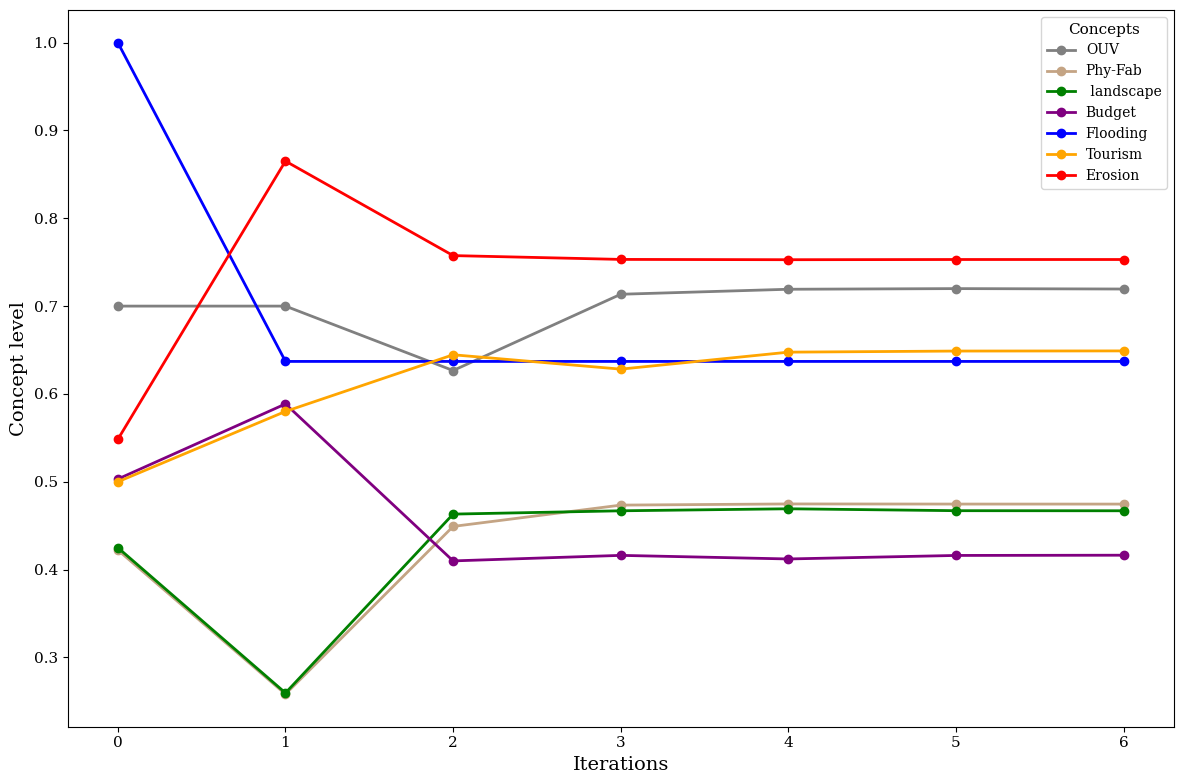

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fcmpy import FcmSimulator
import os

# --- File paths ---
matrix_path = "Experiments/Final Modified_Matrix-Copy1.csv"
initial_values_path = "Experiments/initial values.csv"
labels_path = "Original Data/Concept labels.csv"
output_folder = "Results"
comparison_csv_filename = "comparison_table.csv"
line_plot_filename = "The level of key system components in the FTb scenario.png"

# Ensure output folder exists
os.makedirs(output_folder, exist_ok=True)

# --- Load FCM matrix ---
fcm_data = pd.read_csv(matrix_path, index_col=0)
concept_ids = fcm_data.columns.tolist()
weight_matrix = fcm_data.astype(float).values

# --- Load concept labels ---
labels_df = pd.read_csv(labels_path)
concept_label_map = dict(zip(labels_df['Concept ID'], labels_df['Label']))
concept_labels = [concept_label_map.get(cid, cid) for cid in concept_ids]

# --- Load initial values ---
def get_initial_values():
    df = pd.read_csv(initial_values_path)
    if 'Concept ID' not in df.columns or 'Initial Value' not in df.columns:
        raise ValueError("CSV must have 'Concept ID' and 'Initial Value'")
    return {
        concept_label_map.get(concept, concept): df.loc[df['Concept ID'] == concept, 'Initial Value'].values[0]
        if concept in df['Concept ID'].values else 0.0
        for concept in concept_ids
    }

init_state = get_initial_values()
sim = FcmSimulator()

# --- FCM simulation function ---
def simulate_fcm(initial_state, weight_matrix):
    mod_matrix = weight_matrix.copy()
    inactive = [c for c, v in initial_state.items() if v == 0.0]
    for c in inactive:
        if c in concept_labels:
            idx = concept_labels.index(c)
            mod_matrix[:, idx] = 0
            mod_matrix[idx, :] = 0
    return sim.simulate(
        initial_state=initial_state,
        weight_matrix=mod_matrix,
        transfer='sigmoid',
        inference='kosko',
        thresh=0.001,
        iterations=20,
        l=1
    )

# --- Run Baseline ---
baseline_result = simulate_fcm(init_state, weight_matrix)
baseline_df = pd.DataFrame(baseline_result, columns=concept_labels)
last_values = baseline_df.iloc[-1].to_dict()

# --- Define Interventions ---
def apply_intervention(name, base_state):
    updated = base_state.copy()
    if name == "flood_improvement":
        updated.update({
            concept_label_map['C15']: 1,
            concept_label_map['C11']: 1,
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1,
            concept_label_map['C28']: 0.1
        })
    elif name == "tourism_improvement":
        updated.update({
            concept_label_map['C40']: 1,
            concept_label_map['C21']: 0.1,
            concept_label_map['C28']: 0.1
        })
    elif name == "flood_tourism_improvement":
        updated.update({
            concept_label_map['C15']: 1, 
            concept_label_map['C11']: 1,
            concept_label_map['C40']: 0.5,  
            concept_label_map['C21']: 0.1,
            concept_label_map['C27']: 1,
            concept_label_map['C28']: 0.1
        })
    return updated

# --- Scenarios ---
scenarios = {
    "Baseline": last_values,
    "Flood with Improvement": apply_intervention("flood_improvement", last_values),
    "Tourism with Improvement": apply_intervention("tourism_improvement", last_values),
    "Flood + Tourism with Improvement": apply_intervention("flood_tourism_improvement", last_values),
}

# --- Define target concepts ---
target_concepts = ["C1", "C2", "C3", "C7", "C15","C40","C8"]
target_labels = [concept_label_map[cid] for cid in target_concepts]

# --- Run simulations for all scenarios ---
scenario_results = {}
for name, state in scenarios.items():
    result = simulate_fcm(state, weight_matrix)
    scenario_results[name] = pd.DataFrame(result, columns=concept_labels)

# --- Create comparison CSV for target concepts only ---
comparison_data = {
    scenario: [df.iloc[-1][label] for label in target_labels]
    for scenario, df in scenario_results.items()
}
comparison_df = pd.DataFrame(comparison_data, index=target_labels)
comparison_df.index.name = "Concept Label"

comparison_csv_path = os.path.join(output_folder, comparison_csv_filename)
comparison_df.to_csv(comparison_csv_path)
print(f"Comparison CSV saved at: {comparison_csv_path}")

# --- Line plot for target concepts only ---

# --- Line plot for target concepts only with custom colors ---

# --- Line plot for target concepts only with custom colors ---

plt.figure(figsize=(12, 8))

# Custom colors using concept IDs
concept_colors = {
    "C1": "gray",
    "C2": "#C4A484",  # light brown
    "C3": "green",
    "C7": "purple",
    "C8": "red",
    "C40": "orange",
    "C15": "blue"  # default for missing
}

# Scenario to plot
third_scenario_name = "Flood + Tourism with Improvement"
third_scenario_df = scenario_results[third_scenario_name]

# Plot activation values
for cid in target_concepts:  # use concept IDs
    label = concept_label_map[cid]  # get the actual label for plotting
    plt.plot(
        third_scenario_df[label],
        label=label,
        linewidth=2,
        color=concept_colors[cid],  # use ID to get color
        marker='o',
        markersize=6
    )

# Axes and legend styling
plt.xlabel("Iterations", fontsize=14)
plt.ylabel("Concept level", fontsize=14)
plt.title(f"", fontsize=16)
plt.legend(title="Concepts", loc='upper right', fontsize=10, title_fontsize=11, frameon=True)
plt.tight_layout()

# --- Save figure as PNG and PDF ---
png_filename = "The level of key system components in the FTb scenario.png"
pdf_filename = "The level of key system components in the FTb scenario.pdf"

png_path = os.path.join(output_folder, png_filename)
pdf_path = os.path.join(output_folder, pdf_filename)

plt.savefig(png_path, dpi=300)   # Save as PNG
plt.savefig(pdf_path, dpi=300)   # Save as PDF

print(f"Figure saved as PNG: {png_path}")
print(f"Figure saved as PDF: {pdf_path}")

# Show plot
plt.show()